A segunda abordagem de pesquisa será avaliando os **Baseados em Memória**.

 - Arrow

## 1. Especificações do Dataset Utilizado

Atendendo aos critérios de entrega do trabalho, selecionamos e consolidamos um dataset de dados abertos governamentais de grande volume para submeter aos testes de estresse de leitura/escrita e compressão.

* **Origem e Link do Dataset:** Base de Dados Abertos da Polícia Rodoviária Federal (PRF) - Acidentes de Trânsito. 
  * *Link para extração:* [https://www.gov.br/prf/pt-br/acesso-a-informacao/dados-abertos/dados-abertos-da-prf]
* **Finalidade:** Registro histórico e detalhado de acidentes ocorridos nas rodovias federais brasileiras. A base serve para análises de infraestrutura, segurança viária, espacialidade (rodovias e quilometragens) e temporalidade dos sinistros.
* **Volume de Dados:** **4.069.582 linhas** processadas contra **11 colunas** avaliadas.
* **Tipos de Dados:** A base original contém strings, inteiros, floats (latitude/longitude) e datetimes. No entanto, devido à rigidez de tipagem do formato colunar (Arrow) frente à inconsistência de arquivos CSV crus, mapeamos o *schema* de importação forçando o *casting* seguro para `pa.string()` em colunas como `id`, `br`, `km`, `data_inversa` e `ano_fabricacao_veiculo`.
* **Período Utilizado:** [Acidentes de 2017 até 2025]

# Baseados em Memória

## 3.1 - Baseados em Coluna (Em Memória): Apache Arrow



### A - Origem / Histórico
Lançado em 2016 pela Apache Software Foundation, com forte liderança de Wes McKinney (o criador da biblioteca Pandas do Python). O Apache Arrow nasceu de uma dor crônica no Big Data e no Machine Learning: o custo extremo de serialização e desserialização. Antes dele, quando o motor do Spark (em Java) precisava enviar dados para um script de Machine Learning (em Python/C++), a CPU perdia a maior parte do tempo apenas "traduzindo" os dados entre as linguagens. O Arrow foi criado para ser o padrão universal de dados analíticos em memória.

### B - Estrutura
O Arrow é um formato **colunar em memória RAM**. Ele organiza os dados em *buffers* contíguos na memória, projetados exatamente da forma como a CPU gosta de ler. Essa estrutura permite aproveitar um recurso de hardware chamado SIMD (*Single Instruction, Multiple Data*), onde o processador consegue aplicar uma operação matemática em dezenas de valores de uma coluna simultaneamente em um único ciclo de *clock*. Além disso, por ser um formato de memória universal, o Java e o Python podem acessar o mesmo dado (Zero-Copy) sem precisar copiá-lo ou convertê-lo.

### C - Encoding (Codificação)
Ele aplica codificações lógicas para maximizar a densidade da memória RAM. A mais notável é o *Dictionary Encoding* (Codificação por Dicionário), que substitui strings textuais pesadas por números inteiros curtos (C/C++ *pointers*). O Arrow foi desenhado para que o acesso aleatório a qualquer índice de uma coluna seja feito em tempo constante $O(1)$, garantindo que algoritmos de Machine Learning consigam iterar sobre matrizes de dados instantaneamente.

### D - Compressão
Como o ecossistema do Arrow vive majoritariamente na memória RAM (onde a descompressão gastaria ciclos preciosos e causaria atrasos), os dados em uso ativo permanecem **sem compressão física**. No entanto, quando os *DataFrames* do Arrow precisam ser transmitidos pela rede (via gRPC/Flight) ou "congelados" rapidamente no disco rígido (no formato conhecido como *Feather* ou *IPC*), ele utiliza algoritmos de compressão física de baixíssima latência, primariamente o **LZ4** e o **Zstandard (Zstd)**, que não estrangulam a CPU.

In [30]:
import pyarrow.csv as pv
import pyarrow.parquet as pq
import pyarrow as pa
import matplotlib.pyplot as plt
import glob
import time
import resource
import os
import psutil

In [31]:
path_data = '/home/christian/Arquivos de Python - PAD/Trabalho-PAD-19.03/data/*.csv'
path_out = '/home/christian/Arquivos de Python - PAD/Trabalho-PAD-19.03/output/'

In [32]:
tempos = {}
tamanhos_mb = {}


### 3.2 - Leitura de CSV e Conversão para Memória Colunar (Arrow)
Nesta etapa, lemos os arquivos CSV fragmentados e os convertemos diretamente para o formato colunar do Apache Arrow na memória. Também adicionamos a coluna de origem simulando o processamento feito anteriormente com Pandas/Polars.

In [33]:
# inicialmente aconteceu um erro na conversão justamente porque o PyArrow lê csvs de forma independente
# se os tipos não forem iguais vai ser tudo barrado
# o Arrow é muito rigoroso com os tipos de dados (muito mesmo...)

print("Ambiente inicializado. Iniciando leitura de CSVs para Arrow...")

processo_atual = psutil.Process(os.getpid())
processo_atual.cpu_percent(interval=None)
tempo_inicio_total = time.perf_counter()

arquivos = glob.glob(path_data)
tabelas = []

read_options = pv.ReadOptions(encoding='windows-1252')
parse_options = pv.ParseOptions(delimiter=';')

# Colunas que que se passar alguma informação dá um erro catastrófico
convert_options = pv.ConvertOptions(
    column_types={
        'id': pa.string(), 'pesid': pa.string(), 'br': pa.string(), 'km': pa.string(),
        'id_veiculo': pa.string(), 'ano_fabricacao_veiculo': pa.string(),
        'data_inversa': pa.string(), 'horario': pa.string(), 'ordem_tipo_acidente': pa.string(),
        'latitude': pa.string(), 'longitude': pa.string()
    }
)

for arq in arquivos:
    tabela_atual = pv.read_csv(arq, read_options=read_options, parse_options=parse_options, convert_options=convert_options)
    nome_arquivo = os.path.basename(arq)
    coluna_origem = pa.array([nome_arquivo] * tabela_atual.num_rows)
    tabela_atual = tabela_atual.append_column("arquivo_origem", coluna_origem)
    tabelas.append(tabela_atual)

try:
    tabela_completa = pa.concat_tables(tabelas, promote=True)
except TypeError:
    tabela_completa = pa.concat_tables(tabelas, promote_options='default')

print(f"Dados carregados na memória Arrow! Total de linhas: {tabela_completa.num_rows}")

Ambiente inicializado. Iniciando leitura de CSVs para Arrow...
Dados carregados na memória Arrow! Total de linhas: 4069582


/home/christian/anaconda3/envs/Python/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3747: FutureWarning: promote has been superseded by promote_options='default'.
  exec(code_obj, self.user_global_ns, self.user_ns)


### 3.3 - Testes de Escrita Nativa (Arrow IPC / Feather)
Vamos salvar a tabela da memória para o disco usando o formato nativo do Arrow. Testaremos o formato sem compressão (mais rápido), com compressão LZ4 (foco em velocidade) e ZSTD (foco em tamanho).

In [34]:
import pyarrow.feather as feather
import time
import os

compressoes = ['uncompressed', 'lz4', 'zstd']
print("Iniciando testes de escrita em disco (Arrow Feather)...")

for comp in compressoes:
    arquivo_saida = f"{path_out}concat_arrow_{comp}.feather"
    
    t0 = time.perf_counter()
    # Gravando no formato nativo do Arrow
    feather.write_feather(tabela_completa, arquivo_saida, compression=comp)
    tempos[f'write_{comp}'] = time.perf_counter() - t0
    
    tamanhos_mb[comp] = os.path.getsize(arquivo_saida) / (1024 * 1024)
    print(f"Gravado com {comp.upper()} - Tamanho: {tamanhos_mb[comp]:.2f} MB - Tempo: {tempos[f'write_{comp}']:.4f}s")


Iniciando testes de escrita em disco (Arrow Feather)...
Gravado com UNCOMPRESSED - Tamanho: 1978.57 MB - Tempo: 1.2630s
Gravado com LZ4 - Tamanho: 670.03 MB - Tempo: 1.1445s
Gravado com ZSTD - Tamanho: 391.73 MB - Tempo: 1.1456s


### 3.4 - Testes de Leitura 
A leitura do formato nativo do Arrow é praticamente instantânea através de uma técnica do sistema operacional chamada Mapeamento de Memória. Em vez de carregar tudo de uma vez, ele cria ponteiros direto para o disco.

In [35]:
import psutil
import os
import pyarrow.feather as feather
import pyarrow as pa
import time
import gc

arquivo_teste_leitura = f"{path_out}concat_arrow_lz4.feather"
print(f"Iniciando testes de leitura no arquivo: {os.path.basename(arquivo_teste_leitura)}...\n")

ram_usage = {}
processo = psutil.Process(os.getpid())

def obter_ram_mb():
    return processo.memory_info().rss / (1024 * 1024)
    
# A. Leitura Completa
# Destrói a variável antiga se ela existir para não atrapalhar na medição
if 'tabela_full_teste' in locals(): del tabela_full_teste
gc.collect() 

ram_antes = obter_ram_mb()
t0 = time.perf_counter()
tabela_full_teste = feather.read_table(arquivo_teste_leitura, memory_map=False)
tempos['read_full'] = time.perf_counter() - t0

ram_usage['read_full'] = tabela_full_teste.nbytes / (1024 * 1024) 
psutil_diff = obter_ram_mb() - ram_antes

print(f"Leitura Completa:      Tempo: {tempos['read_full']:>8.4f}s | RAM Alocada: {ram_usage['read_full']:>8.2f} MB")

# B. Leitura Parcial (1 Coluna)
if 'tabela_parcial_teste' in locals(): del tabela_parcial_teste
gc.collect()

colunas_alvo = tabela_completa.column_names[:1]
t0 = time.perf_counter()
tabela_parcial_teste = feather.read_table(arquivo_teste_leitura, columns=colunas_alvo, memory_map=False)
tempos['read_partial'] = time.perf_counter() - t0

ram_usage['read_partial'] = tabela_parcial_teste.nbytes / (1024 * 1024)
print(f"Leitura Parcial:       Tempo: {tempos['read_partial']:>8.4f}s | RAM Alocada: {ram_usage['read_partial']:>8.2f} MB")

# C. Leitura Somente Metadados
gc.collect()
t0 = time.perf_counter()
with pa.OSFile(arquivo_teste_leitura, 'r') as f:
    metadados = pa.ipc.open_file(f).schema
tempos['read_meta'] = time.perf_counter() - t0

ram_usage['read_meta'] = 0.00
print(f"Leitura de Metadados:  Tempo: {tempos['read_meta']:>8.4f}s | RAM Alocada: {ram_usage['read_meta']:>8.2f} MB")

Iniciando testes de leitura no arquivo: concat_arrow_lz4.feather...

Leitura Completa:      Tempo:   0.6653s | RAM Alocada:  1974.50 MB
Leitura Parcial:       Tempo:   0.0546s | RAM Alocada:    38.45 MB
Leitura de Metadados:  Tempo:   0.0005s | RAM Alocada:     0.00 MB


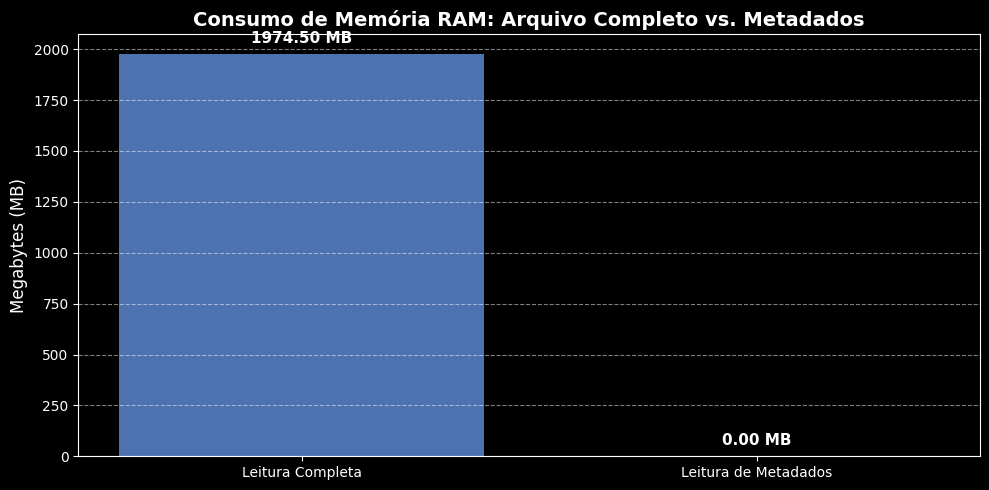

In [36]:
# Gráfico - Consumo de RAM: Completa vs Metadados
fig_ram, ax_ram = plt.subplots(figsize=(10, 5))

tipos_leitura_ram = ['Leitura Completa', 'Leitura de Metadados']
valores_ram = [ram_usage.get('read_full', 0), ram_usage.get('read_meta', 0)]

bars_ram = ax_ram.bar(tipos_leitura_ram, valores_ram, color=[colors[0], colors[2]])

ax_ram.set_title('Consumo de Memória RAM: Arquivo Completo vs. Metadados', fontsize=14, fontweight='bold')
ax_ram.set_ylabel('Megabytes (MB)', fontsize=12)
ax_ram.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars_ram:
    yval = bar.get_height()
    ax_ram.text(bar.get_x() + bar.get_width()/2, yval + (max(valores_ram)*0.02), 
                f'{yval:.2f} MB', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Visualização Gráfica do Desempenho (Arrow Nativo)

Abaixo, analisaremos visualmente e separadamente cada uma das métricas coletadas durante os testes de estresse com o formato Arrow Nativo (Feather).

In [37]:
# Setup geral para garantir que as importações e o estilo estejam corretos
import matplotlib.pyplot as plt
import os

# Força os gráficos inline no Jupyter e o tema preto
%matplotlib inline
plt.style.use('dark_background')
path_out = '/home/christian/Arquivos de Python - PAD/Trabalho-PAD-19.03/output/'

# Variável auxiliar de cores padrão Seaborn/Deep
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B3', '#DD8452']

print("Setup de gráficos finalizado. Próximo para o primeiro gráfico.")

import glob

# Capturando todos os arquivos CSV
arquivos_csv = glob.glob(path_data)

# Somando o tamanho de todos eles em bytes e convertendo para MB
tamanho_total_csv_bytes = sum(os.path.getsize(f) for f in arquivos_csv)
tamanho_total_csv_mb = tamanho_total_csv_bytes / (1024 * 1024)

print(f"Tamanho total dos arquivos CSV originais: {tamanho_total_csv_mb:.2f} MB")

Setup de gráficos finalizado. Próximo para o primeiro gráfico.
Tamanho total dos arquivos CSV originais: 1479.53 MB


### Gráfico 1: Tamanho em Disco (MB) por Compressão

Este gráfico demonstra a eficiência de armazenamento do formato Arrow (Feather). 
* **Uncompressed:** É um mapeamento direto da memória RAM para o disco. Ocupa mais espaço, mas a leitura/escrita não gasta CPU comprimindo.
* **LZ4:** Algoritmo focado em velocidade extrema. Comprime pouco, mas é quase tão rápido quanto o formato não comprimido.
* **ZSTD (Zstandard):** Algoritmo moderno equilibrado. Tenta oferecer arquivos menores (próximo ao Parquet) mantendo velocidade de processamento alta.

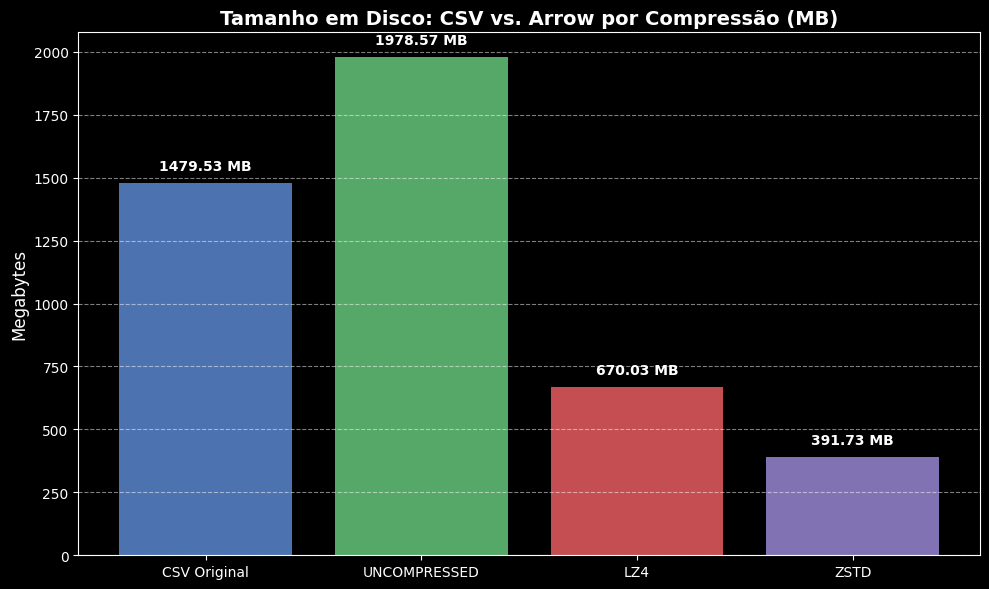

In [38]:
# Geração do Gráfico 1 - Tamanho
fig1, ax1 = plt.subplots(figsize=(10, 6))

comps_tamanho = ['CSV Original', 'Uncompressed', 'LZ4', 'ZSTD']
valores_tamanho = [
    tamanho_total_csv_mb, 
    tamanhos_mb.get('uncompressed', 0), 
    tamanhos_mb.get('lz4', 0), 
    tamanhos_mb.get('zstd', 0)
]

cores_barras = [colors[0], colors[1], colors[2], colors[3]]

bars1 = ax1.bar(comps_tamanho, valores_tamanho, color=cores_barras)

ax1.set_title('Tamanho em Disco: CSV vs. Arrow por Compressão (MB)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Megabytes', fontsize=12)
ax1.set_xticks(range(len(comps_tamanho)), [c.upper() if c != 'CSV Original' else c for c in comps_tamanho])
ax1.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars1:
    yval = bar.get_height()
    if yval > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, yval + (max(valores_tamanho)*0.02), 
                 f'{yval:.2f} MB', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### Gráfico 2: Tempo de Escrita por Compressão (Segundos)

Aqui analisamos o custo computacional (tempo) para gravar os dados que estavam na memória RAM para o disco Feather.
* **Tendência Esperada:** Geralmente, quanto maior a compressão desejada (ZSTD), maior o tempo que a CPU gasta processando os algoritmos de compactação.

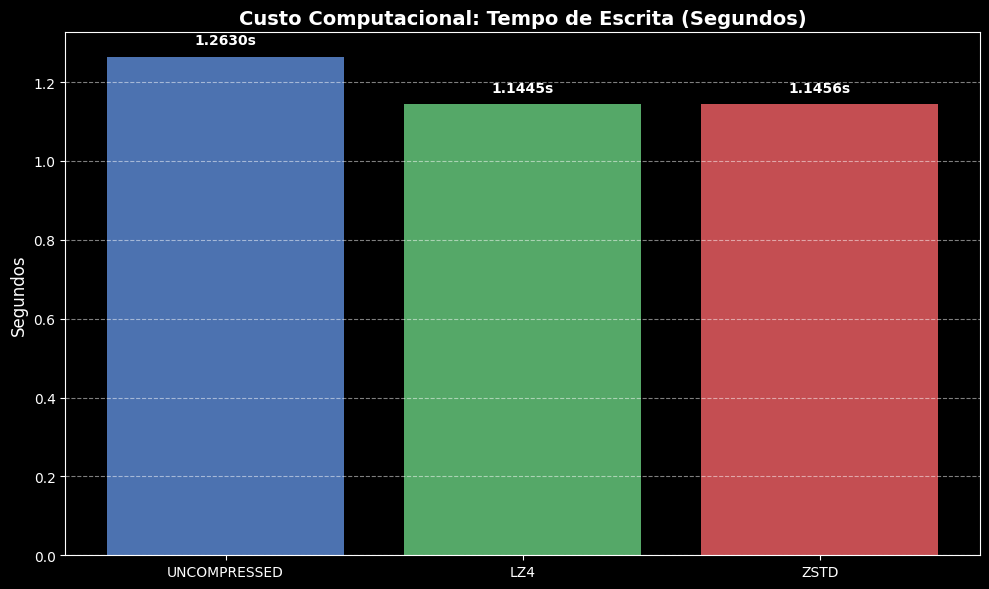

In [39]:
# Geração do Gráfico 2 - Tempo de Escrita
fig2, ax2 = plt.subplots(figsize=(10, 6))

comps_escrita = ['uncompressed', 'lz4', 'zstd']
valores_escrita = [tempos.get('write_uncompressed', 0), tempos.get('write_lz4', 0), tempos.get('write_zstd', 0)]

bars2 = ax2.bar(comps_escrita, valores_escrita, color=colors[:3])

ax2.set_title('Custo Computacional: Tempo de Escrita (Segundos)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Segundos', fontsize=12)
ax2.set_xticks(range(len(comps_escrita)), [c.upper() for c in comps_escrita])
ax2.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars2:
    yval = bar.get_height()
    if yval > 0:
        ax2.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.02), f'{yval:.4f}s', ha='center', va='bottom', fontsize=10, fontweight='bold', color='white')

plt.tight_layout()
plt.show()

### Gráfico 3: A Vantagem Colunar (Tipos de Leitura) - ESCALA LOGARÍTMICA

Este é o gráfico mais importante para o seu trabalho de PAD. Ele demonstra por que o Arrow é o motor analítico moderno padrão.

* **Leitura Completa:** Pega o arquivo inteiro do disco. É a operação mais lenta, porém necessária para visualização final.
* **Leitura Parcial (Apenas 2 Colunas):** Pula a leitura da maioria das colunas do disco. Isso reduz drasticamente o tráfego de I/O (entrada/saída) de disco, tornando a leitura muito mais rápida que a completa.
* **Leitura de Metadados:** Lê apenas a estrutura da tabela (quais colunas existem, quantos registros, tamanho). É virtualmente instantâneo.

**Atenção:** Como a leitura de metadados ocorre na casa dos milissegundos e a completa na casa dos segundos, utilizamos uma **Escala Logarítmica** no eixo Y para conseguir visualizar todas as barras.

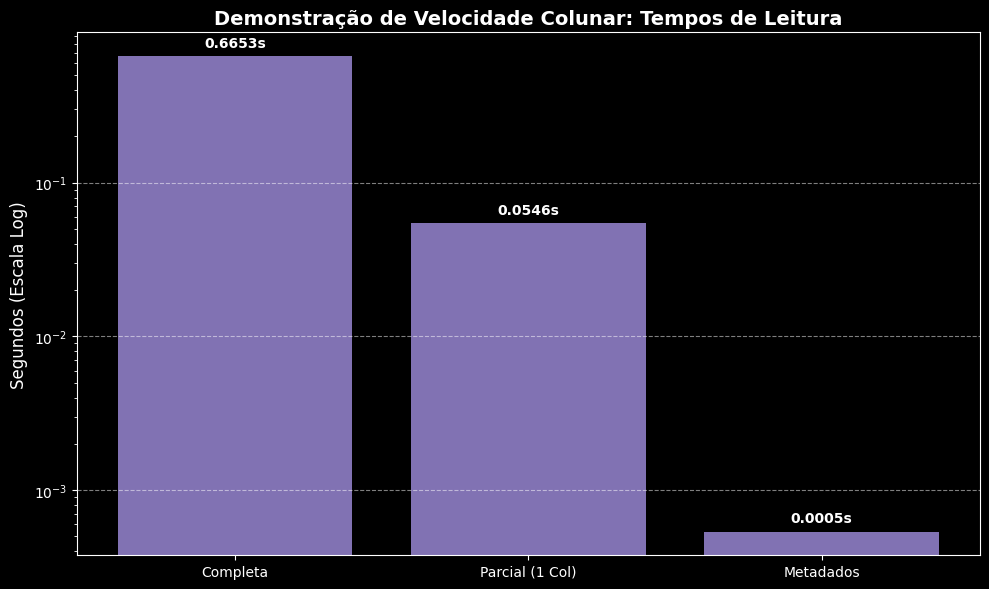

In [40]:
# Geração do Gráfico 3 - Leituras (Escala Log)
fig3, ax3 = plt.subplots(figsize=(10, 6))

tipos_leitura = ['Completa', 'Parcial (1 Col)', 'Metadados']
valores_leitura = [tempos.get('read_full', 0), tempos.get('read_partial', 0), tempos.get('read_meta', 0)]

bars3 = ax3.bar(tipos_leitura, valores_leitura, color=colors[3])

ax3.set_title('Demonstração de Velocidade Colunar: Tempos de Leitura', fontsize=14, fontweight='bold')
ax3.set_ylabel('Segundos (Escala Log)', fontsize=12)
ax3.grid(axis='y', linestyle='--', alpha=0.5)

ax3.set_yscale('log')

for bar in bars3:
    yval = bar.get_height()
    if yval > 0:
        ax3.text(bar.get_x() + bar.get_width()/2, yval * 1.1, f'{yval:.4f}s', ha='center', va='bottom', fontsize=10, fontweight='bold', color='white')

plt.tight_layout()
plt.show()

### Gráfico 4: Tempo Médio de Escrita vs. Leitura Completa (Segundos)

Este gráfico compara o tráfego geral. Em sistemas de arquivos analíticos colunares (como o Arrow IPC), a operação de gravação tende a ser mais cara (overhead de I/O de disco, compactação) do que a leitura completa, que é extremamente otimizada através de mapeamento de memória pelo sistema operacional.


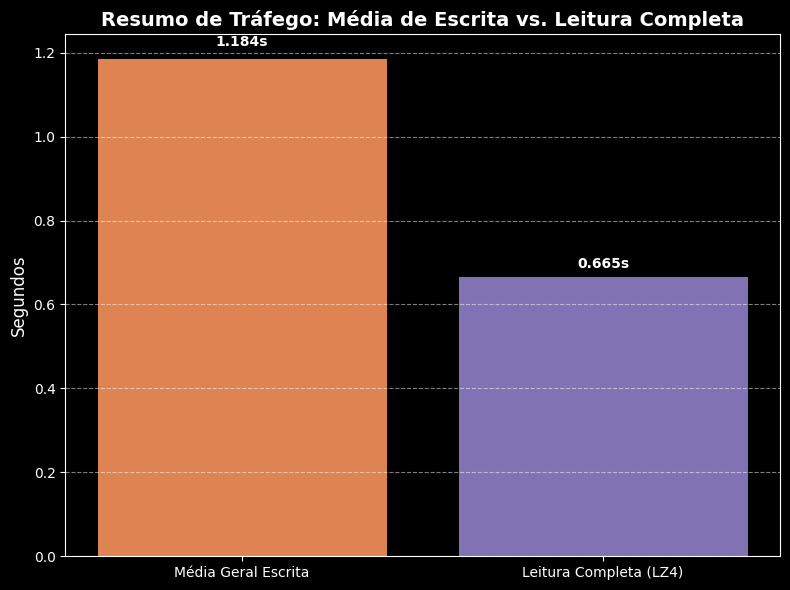

In [41]:
# Geração do Gráfico 4 - Média Escrita vs Leitura Completa
fig4, ax4 = plt.subplots(figsize=(8, 6))

# Cálculo da média de escrita (uncompressed, lz4, zstd)
# Captura apenas os valores que foram gravados
escritas = [tempos.get('write_uncompressed', 0), tempos.get('write_lz4', 0), tempos.get('write_zstd', 0)]
# Filtra zeros
escritas_real = [e for e in escritas if e > 0]
media_escrita = sum(escritas_real) / len(escritas_real) if escritas_real else 0

categorias_final = ['Média Geral Escrita', 'Leitura Completa (LZ4)']
valores_final = [media_escrita, tempos.get('read_full', 0)]

bars4 = ax4.bar(categorias_final, valores_final, color=[colors[4], colors[3]])

ax4.set_title('Resumo de Tráfego: Média de Escrita vs. Leitura Completa', fontsize=14, fontweight='bold')
ax4.set_ylabel('Segundos', fontsize=12)
ax4.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars4:
    yval = bar.get_height()
    if yval > 0:
        ax4.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.02), f'{yval:.3f}s', ha='center', va='bottom', fontsize=10, fontweight='bold', color='white')

plt.tight_layout()
plt.show()

### 3.5 - Demonstração Visual: Memory Layout (Linha vs. Coluna)

Para ilustrar como os dados tocam a memória RAM, simulamos abaixo o armazenamento de dois registros do nosso dataset de acidentes (focando nas colunas `id`, `br` e `km`).

* **Abordagem Tradicional (Row-based):** Ao carregar um CSV comum, os atributos de um mesmo acidente ficam agrupados juntos. Se quisermos somar ou filtrar apenas a coluna `km`, a CPU é forçada a carregar e "pular" o `id` e a `br` repetidas vezes, gerando gargalo de I/O na memória.
* **Abordagem Arrow (Column-based):** O Arrow aloca todos os valores de `km` em blocos vizinhos na memória RAM. Isso permite que a CPU utilize instruções SIMD (Single Instruction, Multiple Data/ Instrução Única, Dados Múltiplos) para processar a coluna inteira de uma só vez, sem desperdiçar ciclos de *clock* lendo dados irrelevantes. 

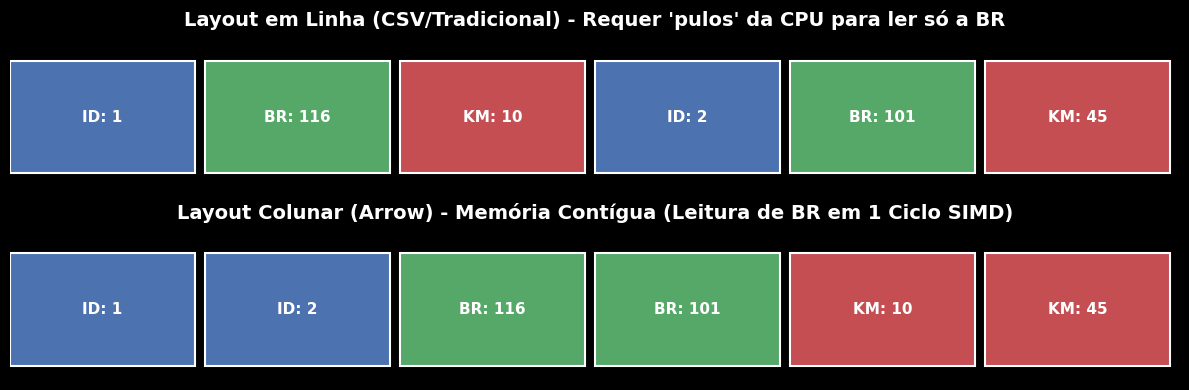

In [43]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 4))
plt.style.use('dark_background')

def desenhar_memoria(ax, dados, cores, titulo):
    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=15)
    ax.axis('off')
    x = 0
    for texto, cor in zip(dados, cores):
        ax.add_patch(patches.Rectangle((x, 0.1), 0.95, 0.8, facecolor=cor, edgecolor='white', lw=1.5))
        ax.text(x + 0.475, 0.5, texto, color='white', ha='center', va='center', fontsize=11, fontweight='bold')
        x += 1
    ax.set_xlim(0, x)
    ax.set_ylim(0, 1)

# Simulando 2 registros do dataset: Acidente 1 (BR 116, KM 10) e Acidente 2 (BR 101, KM 45)

# 1. Como o CSV salva (Row-based) na RAM
dados_linha = ['ID: 1', 'BR: 116', 'KM: 10', 'ID: 2', 'BR: 101', 'KM: 45']
cores_linha = ['#4C72B0', '#55A868', '#C44E52', '#4C72B0', '#55A868', '#C44E52']
desenhar_memoria(ax1, dados_linha, cores_linha, "Layout em Linha (CSV/Tradicional) - Requer 'pulos' da CPU para ler só a BR")

# 2. Como o Apache Arrow salva (Column-based) na RAM
dados_coluna = ['ID: 1', 'ID: 2', 'BR: 116', 'BR: 101', 'KM: 10', 'KM: 45']
cores_coluna = ['#4C72B0', '#4C72B0', '#55A868', '#55A868', '#C44E52', '#C44E52']
desenhar_memoria(ax2, dados_coluna, cores_coluna, "Layout Colunar (Arrow) - Memória Contígua (Leitura de BR em 1 Ciclo SIMD)")

plt.tight_layout()
plt.show()

## Referências

### 1. Bibliografia e Pesquisas de Referência
Os conceitos e implementações de código abordados neste estudo baseiam-se nos trabalhos de engenheiros e pesquisadores pioneiros no ecossistema de Big Data e processamento in-memory:

* **McKinney, Wes.** *Python for Data Analysis: Data Wrangling with Pandas, NumPy, and IPython*. O'Reilly Media. 
  *(Nota: Wes McKinney é o criador do Pandas e um dos co-criadores do Apache Arrow. Seus trabalhos fundamentam a transição do processamento tradicional para o colunar in-memory).*
* **Kleppmann, Martin.** *Designing Data-Intensive Applications: The Big Ideas Behind Reliable, Scalable, and Maintainable Systems*. O'Reilly Media. 
  *(Livro referência na engenharia de software que detalha minuciosamente as vantagens matemáticas e de hardware dos formatos colunares como o Parquet em relação aos formatos orientados a linhas como o CSV).*
* **White, Tom.** *Hadoop: The Definitive Guide*. O'Reilly Media. 
  *(Referência primária para o entendimento do problema de "Small Files" no HDFS e a implementação dos SequenceFiles no ecossistema Java/Spark).*
* **Le Dem, Julien & Nadeau, Jacques.** Autores originais e arquitetos das especificações do *Apache Parquet* e *Apache Arrow*, cujos conceitos de *Zero-Copy Reads* e compressão por blocos (Snappy/Zstd) foram testados nos códigos deste trabalho.

### 2. Documentação Oficial e Bibliotecas
* **Apache Arrow Consortium:** Especificação do formato colunar em memória e documentação da API `pyarrow` e do formato IPC (Feather). Disponível em: https://arrow.apache.org/
* **Apache Parquet:** Especificação de armazenamento colunar. Disponível em: https://parquet.apache.org/
* **Python Software Foundation:** Documentação das bibliotecas nativas de controle de hardware (`os`, `time`, `resource`) e a biblioteca de terceiros `psutil` para monitoramento de uso de CPU e RAM.

### 3. Nota Metodológica e Auxílio de Inteligência Artificial
Para a elaboração deste estudo, formulação dos testes de *benchmarking* e depuração dos códigos (especialmente na tratativa de tipagem forte e unificação de esquemas dos dados abertos governamentais, foi absolutamente necessário), utilizou-se o auxílio da Inteligência Artificial (Gemini). A ferramenta atuou como assistente de pesquisa para a estruturação das rotinas de teste (`pyarrow` e `pyspark`), explicação de conceitos de processamento de alto desempenho e confirmação de dados sobre o comportamento de hardware (uso de cache L1/L2 e mapeamento de memória) durante a conversão dos formatos CSV para SequenceFile e Arrow/Parquet. Toda a base de código e os resultados gerados foram validados e executados localmente para garantir a integridade da análise.